# Bayesian Optimization Hands-on (Colab Ready)
This notebook uses **scikit-optimize (skopt)** with a Gaussian Process surrogate to optimize the **Branin** function.

### What you'll learn
1. How GP-based Bayesian Optimization works in practice (minimization)
2. How to inspect convergence and the proposed points
3. How to use the **ask–tell** loop (sequential, adaptive design)

Run the cells from top to bottom. Works in **Google Colab** or locally.

## 0) Setup

In [2]:
!pip -q install scikit-optimize matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 7.8 MB/s eta 0:00:00


## 1) Imports & Objective (Branin)
We minimize the Branin function (a 2D benchmark with multiple minima).

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skopt import gp_minimize
from skopt.space import Real
from skopt.plots import plot_convergence
from skopt.utils import cook_estimator

# Branin function (to minimize). Domain: x in [-5, 10], y in [0, 15].
def branin(xy):
    # Ensure xy can handle both scalar and array inputs
    x, y = xy
    a = 1.0
    b = 5.1 / (4.0*np.pi**2)
    c = 5.0/np.pi
    r = 6.0
    s = 10.0
    t = 1.0/(8.0*np.pi)
    return a*(y-b*x**2+c*x-r)**2 + s*(1-t)*np.cos(x) + s

bounds = [Real(-5.0, 10.0, name='x'), Real(0.0, 15.0, name='y')]
print('Branin at (pi, 2.275) ≈', branin([np.pi, 2.275]))

Branin at (pi, 2.275) ≈ 0.39788735772973816


## 2) One-line GP Bayesian Optimization

Best y (min): 0.3981483634762242
Best x: [-3.1488314497551846, 12.28933239028874]


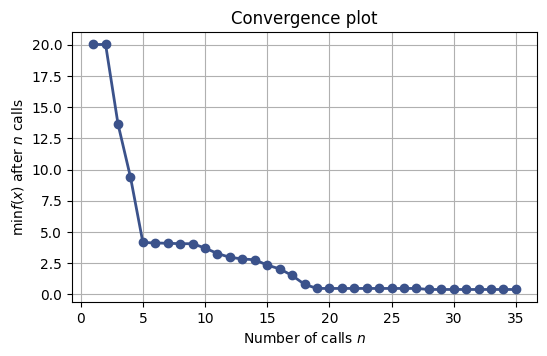

In [4]:

# Run GP-based BO with Expected Improvement by default
res = gp_minimize(
    func=branin,
    dimensions=bounds,
    n_calls=35,           # total evaluations
    n_initial_points=5,   # random starts
    noise=0.0,            # set >0 if your function is noisy
    random_state=42
)

print('Best y (min):', res.fun)
print('Best x:', res.x)

# Convergence plot
ax = plot_convergence(res); ax.figure.set_size_inches(6,3.5); plt.show()


## 3) Visualize sampled points on the landscape

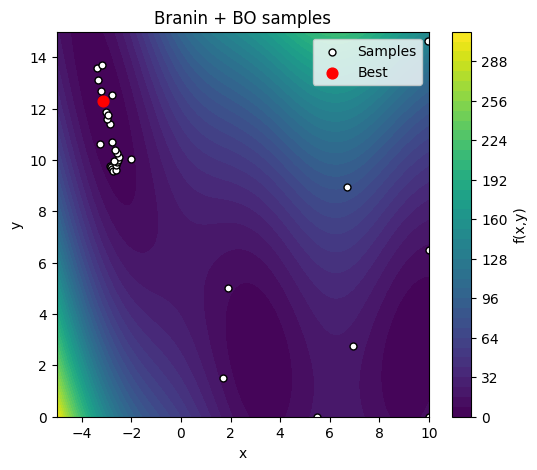

In [11]:
# Draw the Branin landscape and the sampled points
xs = np.linspace(-5, 10, 200)
ys = np.linspace(0, 15, 200)
X, Y = np.meshgrid(xs, ys)
Z = branin([X, Y]) # Call branin with meshgrid arrays directly

plt.figure(figsize=(6,5))
cs = plt.contourf(X, Y, Z, levels=40)
plt.colorbar(cs, label='f(x,y)')
plt.scatter(np.array(res.x_iters)[:,0], np.array(res.x_iters)[:,1], s=25, c='w', edgecolors='k', label='Samples')
plt.scatter([res.x[0]], [res.x[1]], c='red', s=60, label='Best')
plt.title('Branin + BO samples')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.show()

# 4) Live monitoring: GP mean/uncertainty + EI map (5s delay per step)

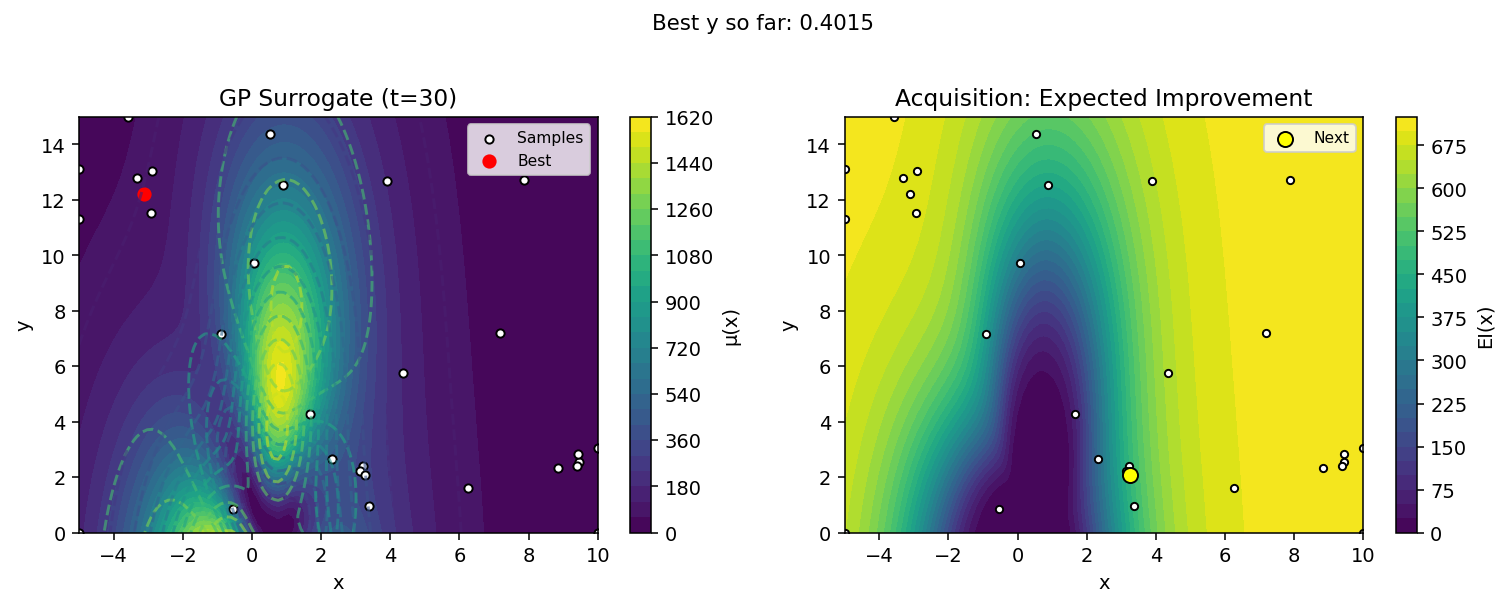

Finished. Best y: 0.40150928469798863 at [-3.114244922466205, 12.203765575987244]


In [14]:
# Live monitoring of GP-based Bayesian Optimization (Branin, minimization)
!pip -q install scikit-optimize matplotlib numpy

import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from skopt import Optimizer
from skopt.space import Real
from skopt.acquisition import gaussian_ei

# --- objective: Branin (minimize) ---
def branin(xy):
    x, y = xy
    a = 1.0
    b = 5.1 / (4.0*np.pi**2)
    c = 5.0/np.pi
    r = 6.0
    s = 10.0
    t = 1.0/(8.0*np.pi)
    return a*(y-b*x**2+c*x-r)**2 + s*(1-t)*np.cos(x) + s

bounds = [Real(-5.0, 10.0, name='x'),
          Real(0.0, 15.0, name='y')]

# --- settings ---
n_init  = 5      # 초기 랜덤/탐색 점 개수
n_iter  = 25     # 라이브 단계 수
grid_n  = 100    # 그리드 해상도
delay_s = 5      # 점 사이 지연(초)

# --- optimizer (GP + EI) ---
opt = Optimizer(
    dimensions=bounds,
    base_estimator="GP",   # ✅ cook_estimator 대신 문자열로 지정
    acq_func="EI",
    random_state=0
)

# --- warm start ---
xs_all, ys_all = [], []
for _ in range(n_init):
    x_next = opt.ask()
    y_next = branin(x_next)
    xs_all.append(x_next); ys_all.append(y_next)
    opt.tell(x_next, y_next)

# --- grid for plotting ---
xs = np.linspace(bounds[0].low, bounds[0].high, grid_n)
ys = np.linspace(bounds[1].low, bounds[1].high, grid_n)
Xg, Yg = np.meshgrid(xs, ys)
XYg = np.c_[Xg.ravel(), Yg.ravel()]

# --- live loop ---
for t in range(n_iter):
    # ask/eval/tell
    x_next = opt.ask()
    y_next = branin(x_next)
    xs_all.append(x_next); ys_all.append(y_next)
    opt.tell(x_next, y_next)

    # GP 모델이 아직 없을 수 있으니 방어
    if not opt.models:
        clear_output(wait=True)
        print(f"t={t + n_init + 1}: warming up...")
        time.sleep(delay_s)
        continue

    # latest GP → μ, σ, EI
    model = opt.models[-1]
    mu, std = model.predict(XYg, return_std=True)
    mu = mu.reshape(Xg.shape); std = std.reshape(Xg.shape)
    y_opt = float(np.min(ys_all))
    EI = gaussian_ei(XYg, model, y_opt=y_opt).reshape(Xg.shape)

    # draw
    clear_output(wait=True)
    fig, axs = plt.subplots(1, 2, figsize=(11, 4.2), dpi=140)

    im0 = axs[0].contourf(Xg, Yg, mu, levels=30)
    fig.colorbar(im0, ax=axs[0]).set_label("μ(x)")
    axs[0].contour(Xg, Yg, mu + std, levels=10, linestyles="--", alpha=0.6)
    axs[0].contour(Xg, Yg, mu - std, levels=10, linestyles="--", alpha=0.6)
    pts = np.array(xs_all); best_idx = int(np.argmin(ys_all))
    axs[0].scatter(pts[:,0], pts[:,1], s=18, c="w", edgecolors="k", label="Samples")
    axs[0].scatter(pts[best_idx,0], pts[best_idx,1], c="red", s=40, label="Best")
    axs[0].set_title(f"GP Surrogate (t={t + n_init + 1})")
    axs[0].set_xlabel("x"); axs[0].set_ylabel("y"); axs[0].legend(loc="upper right", fontsize=8)

    im1 = axs[1].contourf(Xg, Yg, EI, levels=30)
    fig.colorbar(im1, ax=axs[1]).set_label("EI(x)")
    axs[1].scatter(pts[:,0], pts[:,1], s=14, c="w", edgecolors="k")
    axs[1].scatter(x_next[0], x_next[1], c="yellow", edgecolors="k", s=60, label="Next")
    axs[1].set_title("Acquisition: Expected Improvement")
    axs[1].set_xlabel("x"); axs[1].set_ylabel("y"); axs[1].legend(loc="upper right", fontsize=8)

    plt.suptitle(f"Best y so far: {y_opt:.4f}", y=1.02, fontsize=11)
    plt.tight_layout(); display(fig); plt.close(fig)

    time.sleep(delay_s)

print("Finished. Best y:", np.min(ys_all), "at", xs_all[int(np.argmin(ys_all))])


# 5) Manual Optimization (Human-in-the-loop)

In [15]:
# Human-in-the-loop optimization on Branin (no BO) — 35 trials
# - You propose (x, y), get f(x,y) feedback, and see only an interpolated map from your tried points
# - Goal: drive the best value as low as possible within the budget (minimization)
# - Optional: turn on widgets UI with sliders and buttons

from google.colab import output
output.enable_custom_widget_manager()

USE_WIDGETS = True  # <- 슬라이더 UI 쓰려면 True, 텍스트 입력만 하려면 False

!pip -q install numpy matplotlib scipy ipywidgets

import numpy as np, matplotlib.pyplot as plt, time, sys, math
from IPython.display import clear_output, display
from scipy.interpolate import Rbf, LinearNDInterpolator
import warnings
warnings.filterwarnings("ignore")

# 0) Objective: Branin (minimize). Domain: x in [-5, 10], y in [0, 15].
def branin(xy):
    x, y = xy
    a = 1.0
    b = 5.1 / (4.0*np.pi**2)
    c = 5.0/np.pi
    r = 6.0
    s = 10.0
    t = 1.0/(8.0*np.pi)
    return a*(y-b*x**2+c*x-r)**2 + s*(1-t)*np.cos(x) + s

X_BOUND = (-5.0, 10.0)
Y_BOUND = ( 0.0, 15.0)

# 1) Config
BUDGET = 35           # 총 시도 횟수
N_SEED = 3            # 랜덤 시드 포인트 (초기 샘플)
GRID_N = 120          # 배경 등고선 해상도

# 2) Storage
xs, ys, vals = [], [], []
best_val, best_xy = np.inf, None

# 3) Helpers
def in_bounds(x, y):
    return (X_BOUND[0] <= x <= X_BOUND[1]) and (Y_BOUND[0] <= y <= Y_BOUND[1])

def evaluate_and_update(x, y):
    global best_val, best_xy
    v = float(branin((x, y)))
    xs.append(x); ys.append(y); vals.append(v)
    if v < best_val:
        best_val, best_xy = v, (x, y)

def make_interpolant():
    if len(xs) >= 6:
        try:
            return Rbf(np.array(xs), np.array(ys), np.array(vals), function='multiquadric', smooth=0.0)
        except Exception:
            pass
    if len(xs) >= 3:
        try:
            return LinearNDInterpolator(np.c_[np.array(xs), np.array(ys)], np.array(vals))
        except Exception:
            pass
    return None

def draw_status(step, show_truth=False):
    clear_output(wait=True)
    fig, ax = plt.subplots(1, 1, figsize=(6.5, 5), dpi=140)
    xs_lin = np.linspace(*X_BOUND, GRID_N)
    ys_lin = np.linspace(*Y_BOUND, GRID_N)
    Xg, Yg = np.meshgrid(xs_lin, ys_lin)

    if show_truth:
        Z = branin((Xg, Yg))
        cs = ax.contourf(Xg, Yg, Z, levels=40)
        plt.colorbar(cs, ax=ax, label='True f(x,y)')
    else:
        interp = make_interpolant()
        if interp is not None:
            try:
                Zest = interp(Xg, Yg)
                Zplot = np.array(Zest, dtype=float)
                cs = ax.contourf(Xg, Yg, Zplot, levels=30)
                plt.colorbar(cs, ax=ax, label='Interpolated (from tried points)')
            except Exception:
                pass

    if xs:
        sc = ax.scatter(xs, ys, c=vals, s=35, cmap='viridis', edgecolors='k')
        ax.scatter([best_xy[0]], [best_xy[1]], c='red', s=60, label='Best so far', edgecolors='k')

    ax.set_xlim(*X_BOUND); ax.set_ylim(*Y_BOUND)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(f'Human-in-the-loop — step {step}/{BUDGET}\nBest f={best_val:.4f} at {best_xy}')
    ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    display(fig)
    plt.close(fig)

def random_baseline(n):
    rx = np.random.uniform(X_BOUND[0], X_BOUND[1], size=n)
    ry = np.random.uniform(Y_BOUND[0], Y_BOUND[1], size=n)
    rv = [branin((rx[i], ry[i])) for i in range(n)]
    return float(np.min(rv)), (float(rx[int(np.argmin(rv))]), float(ry[int(np.argmin(rv))]))

# 4) Seed points
np.random.seed(0)
for _ in range(N_SEED):
    x0 = np.random.uniform(*X_BOUND)
    y0 = np.random.uniform(*Y_BOUND)
    evaluate_and_update(x0, y0)

# 5A) Text-input loop (터미널 입력)
def text_loop():
    step = len(xs)
    while step < BUDGET:
        draw_status(step, show_truth=False)
        print(f"[{step}/{BUDGET}] Enter next point x y (or commands: 'reveal', 'stop'):")
        s = input().strip()
        if s.lower() in ('stop','exit','quit'):
            break
        if s.lower().startswith('reveal'):
            draw_status(step, show_truth=True); time.sleep(3)
            continue
        try:
            x_str, y_str = s.split()
            x, y = float(x_str), float(y_str)
            if not in_bounds(x, y):
                print(f"Out of bounds! x in {X_BOUND}, y in {Y_BOUND}")
                time.sleep(1.2); continue
            evaluate_and_update(x, y)
            step += 1
        except Exception:
            print("Please type two numbers, e.g. 3.14 2.27  (or 'stop')")
            time.sleep(1.2)
    draw_status(step, show_truth=False)
    print(f"Your best: f={best_val:.6f} at {best_xy}")
    rb, rb_xy = random_baseline(BUDGET)
    print(f"Random baseline (same budget): f={rb:.6f} at {rb_xy}")
    print("Known global minima of Branin ≈ 0.397887 (three locations).")

# 5B) Widgets loop (슬라이더 UI)
def widgets_loop():
    import ipywidgets as W
    try:
        from google.colab import output as colab_output
        colab_output.enable_custom_widget_manager()
    except Exception:
        pass

    xw = W.FloatSlider(description='x', min=X_BOUND[0], max=X_BOUND[1], step=0.05, value=(X_BOUND[0]+X_BOUND[1])/2)
    yw = W.FloatSlider(description='y', min=Y_BOUND[0], max=Y_BOUND[1], step=0.05, value=(Y_BOUND[0]+Y_BOUND[1])/2)
    btn_eval = W.Button(description='Evaluate', button_style='success')
    btn_reveal = W.Button(description='Reveal truth (peek)', button_style='')
    btn_stop = W.Button(description='Stop', button_style='danger')
    out = W.Output()

    state = {'step': len(xs)}

    def refresh(show_truth=False):
        with out:
            draw_status(state['step'], show_truth=show_truth)

    def on_eval(_):
        if state['step'] >= BUDGET: return
        x, y = float(xw.value), float(yw.value)
        evaluate_and_update(x, y)
        state['step'] += 1
        refresh(False)

    def on_reveal(_):
        refresh(True); time.sleep(2.5); refresh(False)

    def on_stop(_):
        with out:
            clear_output(wait=True)
            print("Stopped by user.")
            rb, rb_xy = random_baseline(BUDGET)
            print(f"Your best: f={best_val:.6f} at {best_xy}")
            print(f"Random baseline: f={rb:.6f} at {rb_xy}")
            print("Known global minima ≈ 0.397887.")

    btn_eval.on_click(on_eval); btn_reveal.on_click(on_reveal); btn_stop.on_click(on_stop)
    box = W.VBox([W.HBox([xw, yw]), W.HBox([btn_eval, btn_reveal, btn_stop]), out])
    display(box)
    refresh(False)

# 6) Run one of the loops
if USE_WIDGETS:
    widgets_loop()
else:
    text_loop()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.1 MB/s eta 0:00:00


## 6) Exercises
1. **Change `n_calls`/`n_initial_points`** and observe convergence speed.
2. **Switch `acq_func`** between 'EI', 'PI', 'LCB' and compare.
3. **Add a constraint**: only accept points with `x + y <= 15`; reject others (assign a large penalty).
4. **Try mixed variables**: replace one `Real` with a `Categorical` and define a toy objective.
5. **Batching**: run the ask–tell loop to pick `k` points per iteration (evaluate in parallel) before the next update.